# 📊 รายงานรวมผลการทดลอง R0–R5 — Identity Resolution

**Notebook เดียวจบ**: โหลดผลการทดลองทุกไฟล์จาก `experiments/` → ตารางรวม → กราฟเปรียบเทียบ → สรุป
ทุกตัวเลขคำนวณสดจากไฟล์ JSON ที่สร้างโดย `exp_lib.evaluate()` (**ไม่มีตัวเลขพิมพ์มือ** — ถ้ารัน experiment ใหม่แล้วไฟล์ผลเปลี่ยน กด Run All ตัวเลข/กราฟทั้งหมดอัปเดตเอง)

## การออกแบบการทดลอง: matrix 2 มิติ (Representation × Decision)

| Representation \\ Decision | Threshold มือ (0.98/0.95) | GA re-decision |
|---|---|---|
| **17 features เดิม** (production) | R0 — baseline | R1 |
| **+ BERT cosine** (feature 18, `all-MiniLM-L6-v2`) | R2 | **R3 — ดีที่สุด** |
| **+ Bloom-Dice** (privacy: ไม่เก็บชื่อ plaintext) | R4 (sweep L) | R5 (sweep L) |

การจัดเป็น matrix ทำให้แยกได้ชัดว่าผลที่ดีขึ้นมาจาก *representation* (เพิ่ม feature) หรือมาจาก *decision rule* (จูน threshold) — ซึ่งเป็นคำถามหลักของการทดลองชุดนี้

## ข้อมูลที่ใช้
- **TEST** = entity-aware split 191,693 scored pairs → ตัวเลข **unbiased** ใช้เปรียบเทียบระหว่าง config
- **FULL** = projection ทั้งระบบ 2,073,842 คู่ + exact-tier (genome จูนบน val แล้ว apply) → ใช้ดูผลกระทบจริงถ้า deploy

## ไฟล์ผลลัพธ์ที่ notebook นี้อ่าน
`r1_results.json` (มี R0 baseline ในไฟล์เดียวกัน) · `r2_results.json` · `r3_results.json` · `r4_privacy_tradeoff.json` (R4/R5 ทุกค่า L) · `r2_r3_fn_recovery.json` · `r1_ga_history.json` / `r3_ga_history.json`

> 🔧 รันจาก Master notebook ได้ตามแบบ Master/Slave: ตั้ง `IS_MASTER = True` แล้วกำหนด `RESULTS_DIR`, `SAVE_FIGS` ก่อน `%run` notebook นี้


In [1]:
# PARAMETER BLOCK — override ได้จาก Master notebook (ตั้ง IS_MASTER = True แล้วกำหนดค่าก่อน %run)
try:
    IS_MASTER
except NameError:
    IS_MASTER = False

if not IS_MASTER:
    RESULTS_DIR = './experiments'   # โฟลเดอร์ไฟล์ผลการทดลอง (.json)
    SAVE_FIGS   = False             # True = เซฟทุกกราฟเป็น .png ลง RESULTS_DIR/figs ด้วย


In [2]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.set_loglevel('error')  # กัน warning เรื่อง font รก output

# ---- โทนสี (จาก palette ที่ผ่านการ validate เรื่อง colorblind-safety แล้ว) ----
SURFACE, GRID = '#fcfcfb', '#e1e0d9'
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
BASELINE_AXIS = '#c3c2b7'

# สีประจำแต่ละ experiment — คงที่ทุกกราฟ (สีตามตัวตน ไม่ใช่ตามอันดับ)
EXP_COLORS = {
    'R0': '#898781',   # baseline = เทากลาง
    'R1': '#2a78d6',
    'R2': '#008300',
    'R3': '#d55181',
    'R4': '#c98500',
    'R5': '#1baf7a',
}

plt.rcParams.update({
    'font.family': ['Leelawadee UI', 'Tahoma', 'DejaVu Sans'],
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'figure.dpi': 110,
    'axes.titlelocation': 'left', 'axes.titleweight': 'bold', 'axes.titlesize': 12,
    'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'font.size': 10,
})

FIG_DIR = Path(RESULTS_DIR) / 'figs'

def style_ax(ax, grid_axis=None):
    """โครงกราฟแบบจาง ๆ ให้ข้อมูลเด่นกว่าเส้นแกน"""
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(BASELINE_AXIS)
    ax.tick_params(length=0)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)

def finish(fig, name):
    if fig.get_layout_engine() is None:
        fig.tight_layout()
    if SAVE_FIGS:
        FIG_DIR.mkdir(exist_ok=True)
        fig.savefig(FIG_DIR / f'{name}.png', bbox_inches='tight', dpi=150)
    plt.show()


In [3]:
RES = Path(RESULTS_DIR)

r1  = json.loads((RES / 'r1_results.json').read_text(encoding='utf-8'))
r2  = json.loads((RES / 'r2_results.json').read_text(encoding='utf-8'))
r3  = json.loads((RES / 'r3_results.json').read_text(encoding='utf-8'))
r4  = json.loads((RES / 'r4_privacy_tradeoff.json').read_text(encoding='utf-8'))
rec = json.loads((RES / 'r2_r3_fn_recovery.json').read_text(encoding='utf-8'))
ga_hist = {
    'R1': json.loads((RES / 'r1_ga_history.json').read_text(encoding='utf-8')),
    'R3': json.loads((RES / 'r3_ga_history.json').read_text(encoding='utf-8')),
}

METRICS = ('TP', 'FP', 'FN', 'REVIEW', 'precision', 'recall', 'F1')
rows = []

def add(exp, config, split, m, L=None):
    rows.append({'exp': exp, 'config': config, 'split': split, 'L': L,
                 **{k: m[k] for k in METRICS}})

for split in ('test', 'full'):
    add('R0', 'R0 · 17f + threshold มือ',   split, r1['rules'][split]['R0_production'])
    add('R1', 'R1 · 17f + GA',              split, r1['rules'][split]['R1_ga'])
    add('R2', 'R2 · +BERT + threshold มือ', split, r2['splits'][split])
    add('R3', 'R3 · +BERT + GA',            split, r3['rules'][split]['R3_ga'])
    for L in r4['L_values']:
        add('R4', f'R4 · Bloom L={L} + threshold มือ', split, r4['per_L'][str(L)]['R4_manual'][split], L)
        add('R5', f'R5 · Bloom L={L} + GA',            split, r4['per_L'][str(L)]['R5_ga'][split], L)

df = pd.DataFrame(rows)
df.to_csv(RES / 'r0_r5_summary_tidy.csv', index=False)   # ตารางรวมทุกผลไว้ไฟล์เดียว เผื่อใช้ต่อ

test = df[df.split == 'test'].set_index('config')
full = df[df.split == 'full'].set_index('config')

# หก configuration หลักที่ใช้เทียบกันในกราฟ (R4/R5 ใช้ตัวแทนที่ L=2000)
MAIN = ['R0 · 17f + threshold มือ', 'R1 · 17f + GA', 'R2 · +BERT + threshold มือ',
        'R3 · +BERT + GA', 'R4 · Bloom L=2000 + threshold มือ', 'R5 · Bloom L=2000 + GA']

# ---------- TL;DR (คำนวณสดจากไฟล์ผล) ----------
best = test.loc[test.F1.idxmax()]
r0_row = test.loc['R0 · 17f + threshold มือ']
r5_2000 = test.loc['R5 · Bloom L=2000 + GA']
rev_drop_test = 1 - test.loc['R3 · +BERT + GA', 'REVIEW'] / test.loc['R1 · 17f + GA', 'REVIEW']
rev_drop_full = 1 - full.loc['R3 · +BERT + GA', 'REVIEW'] / full.loc['R0 · 17f + threshold มือ', 'REVIEW']
rec_any = rec['R3_recovered_any (MATCH or REVIEW)']

print('================ TL;DR ================')
print(f'ดีที่สุด            : {best.name}  F1 = {best.F1:.4f}  (baseline R0 = {r0_row.F1:.4f})')
print(f'REVIEW ลดลง        : test R1→R3 = -{rev_drop_test:.0%}   |   full R0→R3 = -{rev_drop_full:.1%} '
      f"({full.loc['R0 · 17f + threshold มือ', 'REVIEW']:,.0f} → {full.loc['R3 · +BERT + GA', 'REVIEW']:,.0f} คู่)")
print(f"กู้ FN ที่เคยปัดตก : R3 = {rec_any}/{rec['fn_pool_size']} ({rec_any / rec['fn_pool_size']:.1%})"
      f"   vs R2 = {rec['R2_recovered_any (MATCH or REVIEW)']}")
print(f'ราคาของ privacy    : F1(R3) - F1(R5, L=2000) = {best.F1 - r5_2000.F1:.4f} จุด — แทบไม่เสียอะไร')


================ TL;DR ================
ดีที่สุด            : R3 · +BERT + GA  F1 = 0.8373  (baseline R0 = 0.7964)
REVIEW ลดลง        : test R1→R3 = -79%   |   full R0→R3 = -96.8% (86,296 → 2,751 คู่)
กู้ FN ที่เคยปัดตก : R3 = 728/2242 (32.5%)   vs R2 = 282
ราคาของ privacy    : F1(R3) - F1(R5, L=2000) = 0.0044 จุด — แทบไม่เสียอะไร


## 1. ตารางรวมทุก configuration (TEST split)

วิธีอ่านตาราง:
- **FP** (จับคู่ผิด) แพงที่สุด — cost function ให้น้ำหนัก 5 เท่าของ FN (`cost = 5·FP + 1·FN + 0.02·REVIEW`)
- **FN** (ปัดตกคู่จริง) คือ recall ที่หายไป
- **REVIEW** คือภาระงานที่ต้องส่งคนตรวจ — ตัวเลขที่ GA พยายามกดลงโดยไม่แลกกับ FP ที่เพิ่มขึ้น

จุดที่ควรสังเกต:
1. **R2 ต่ำกว่า baseline** (F1 0.7393 < 0.7964) ทั้งที่เพิ่ม BERT เข้าไปแล้ว — เพราะ MLP ตัวใหม่ให้ probability คนละ scale กับตัวเดิม แต่ยังใช้ threshold มือชุดเดิม (0.98/0.95) → recall พังลงเหลือ 0.59 บทเรียนสำคัญ: **เปลี่ยน representation แล้วต้อง re-tune decision เสมอ**
2. แถว R4 ทุกค่า L มี FP ต่ำมาก (14) แต่ FN สูง — อาการเดียวกับ R2 (threshold เดิม conservative เกินไปกับ distribution ใหม่)
3. กลุ่มที่ผ่าน GA (R1/R3/R5) ดัน recall ขึ้นไปแถว 0.71–0.72 พร้อมกดทั้ง FP และ REVIEW ลงพร้อมกัน


In [4]:
disp = test.reset_index().copy()
disp['Lsort'] = disp['L'].fillna(9999)
disp = (disp.sort_values(['exp', 'Lsort'], ascending=[True, False])
            .drop(columns=['exp', 'split', 'L', 'Lsort'])
            .set_index('config'))

(disp.style
     .format({'TP': '{:,.0f}', 'FP': '{:,.0f}', 'FN': '{:,.0f}', 'REVIEW': '{:,.0f}',
              'precision': '{:.4f}', 'recall': '{:.4f}', 'F1': '{:.4f}'})
     .highlight_max(subset=['F1'], props='font-weight:bold; background-color:#cde2fb;')
     .highlight_min(subset=['REVIEW'], props='font-weight:bold;')
     .set_caption('ทุก configuration บน TEST split (191,693 scored pairs) — แถวไฮไลต์ = F1 สูงสุด, REVIEW ตัวหนา = ต่ำสุด'))


,TP,FP,FN,REVIEW,precision,recall,F1
config,,,,,,,
R0 · 17f + threshold มือ,"5,864",88,"1,689","8,783",0.9852,0.6683,0.7964
R1 · 17f + GA,"6,231",23,"1,885","3,116",0.9963,0.7101,0.8292
R2 · +BERT + threshold มือ,"5,157",19,"2,523","1,115",0.9963,0.5877,0.7393
R3 · +BERT + GA,"6,347",38,"1,873",640,0.9940,0.7233,0.8373
R4 · Bloom L=2000 + threshold มือ,"5,158",14,"2,858",766,0.9973,0.5878,0.7397
R4 · Bloom L=1000 + threshold มือ,"5,085",14,"2,931",766,0.9973,0.5795,0.7330
R4 · Bloom L=500 + threshold มือ,"4,991",14,"2,453","1,354",0.9972,0.5688,0.7244
R4 · Bloom L=250 + threshold มือ,"5,001",14,"2,760","1,026",0.9972,0.5699,0.7253
R5 · Bloom L=2000 + GA,"6,303",57,"1,823",700,0.9910,0.7183,0.8329


## 2. เปรียบเทียบ F1 — หก configuration หลัก

R3 ชนะทุกตัว (0.8373) รองลงมาคือ R5 ที่ L=2000 (0.8329 — ห่างกันแค่ **0.0044** แต่ได้ privacy เต็ม ๆ)
สังเกตแท่ง R2 ที่*สั้นกว่า* baseline R0 — หลักฐานว่าการเพิ่ม feature อย่างเดียวโดยไม่จูน threshold ใหม่ ทำให้ผลแย่ลงได้จริง


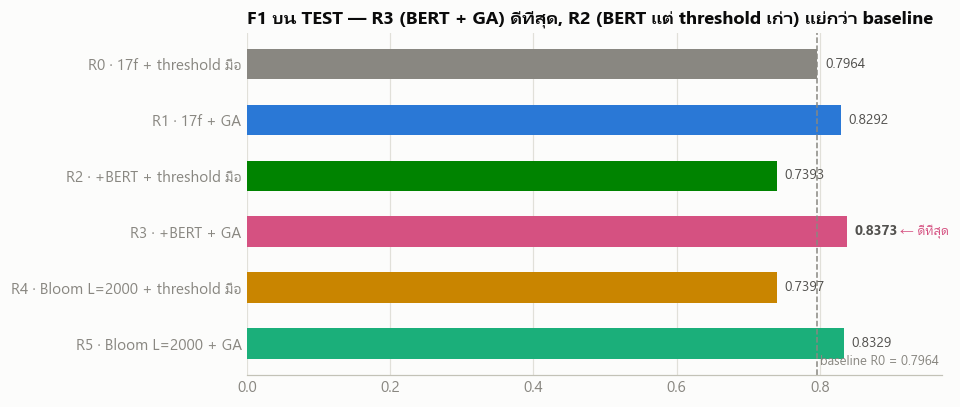

In [5]:
d = test.loc[MAIN]
colors = [EXP_COLORS[e] for e in d.exp]

fig, ax = plt.subplots(figsize=(8.8, 3.8))
bars = ax.barh(range(len(d)), d.F1, height=0.55, color=colors)
ax.set_yticks(range(len(d)), d.index)
ax.invert_yaxis()

labels = ax.bar_label(bars, fmt='%.4f', padding=5, color=INK2, fontsize=9)
best_i = list(d.F1).index(d.F1.max())
labels[best_i].set_fontweight('bold')
ax.text(float(d.F1.max()) + 0.075, best_i, '← ดีที่สุด', va='center', fontsize=9, color=EXP_COLORS['R3'])

r0_f1 = d.iloc[0].F1
ax.axvline(r0_f1, color=MUTED, linestyle='--', linewidth=1)
ax.text(r0_f1 + 0.004, len(d) - 0.62, f'baseline R0 = {r0_f1:.4f}', fontsize=8.5, color=MUTED)

ax.set_xlim(0, 0.97)
ax.set_title('F1 บน TEST — R3 (BERT + GA) ดีที่สุด, R2 (BERT แต่ threshold เก่า) แย่กว่า baseline')
style_ax(ax, grid_axis='x')
finish(fig, 'f1_test')


## 3. Precision–Recall และเพดาน recall จาก blocking

ทุก config อยู่บนโซน precision สูงมาก (>0.985) — สิ่งที่ต่างกันจริง ๆ คือ **recall** และ GA คือกลไกที่เลื่อนจุดไปทางขวา (กู้ recall) โดยแทบไม่เสีย precision เลย

เส้นประแนวตั้งคือ **เพดาน recall = 0.8866**: มีคู่จริง 3,316 คู่ (จากทั้งหมด 29,247) ที่หลุดตั้งแต่ขั้น **blocking** — ไม่เคยถูกสร้างเป็น candidate pair จึงไม่มี score ให้ตัดสินใจ **ไม่มี decision rule หรือ representation ใดในชุดทดลอง R0–R5 กู้คู่กลุ่มนี้ได้** ต้องแก้ด้วย semantic/embedding blocking ซึ่งเป็น experiment แยกต่างหาก


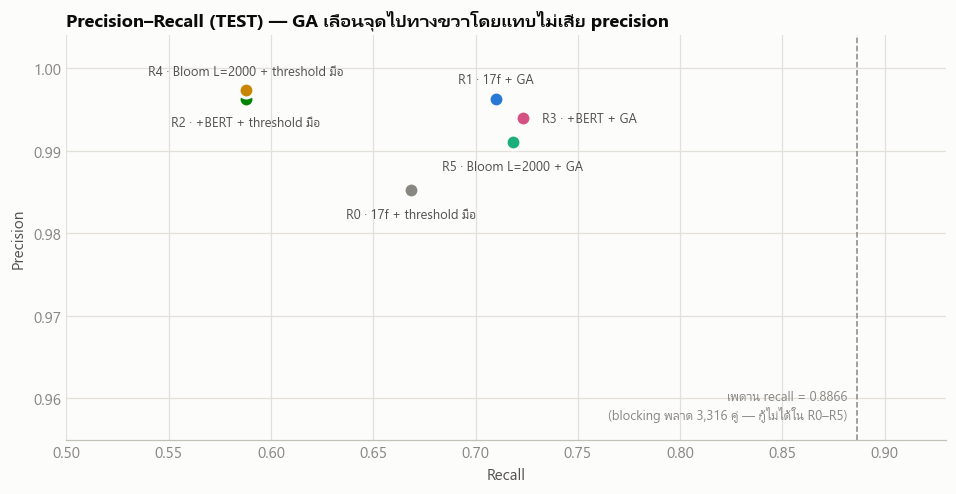

In [6]:
d = test.loc[MAIN]
offsets = {'R0': (0, -18), 'R1': (0, 10), 'R2': (0, -18), 'R3': (12, -3), 'R4': (0, 10), 'R5': (0, -18)}

fig, ax = plt.subplots(figsize=(8.8, 4.6))
for cfg, row in d.iterrows():
    c = EXP_COLORS[row.exp]
    ax.scatter(row.recall, row.precision, s=95, color=c, edgecolor=SURFACE, linewidth=2, zorder=3)
    dx, dy = offsets[row.exp]
    ax.annotate(cfg, (row.recall, row.precision), textcoords='offset points', xytext=(dx, dy),
                ha='center' if dx == 0 else 'left', fontsize=8.5, color=INK2)

ceiling = (29247 - 3316) / 29247
ax.axvline(ceiling, color=MUTED, linestyle='--', linewidth=1)
ax.text(ceiling - 0.005, 0.9575, f'เพดาน recall = {ceiling:.4f}\n(blocking พลาด 3,316 คู่ — กู้ไม่ได้ใน R0–R5)',
        ha='right', fontsize=8.5, color=MUTED)

ax.set_xlim(0.50, 0.93); ax.set_ylim(0.955, 1.004)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision–Recall (TEST) — GA เลื่อนจุดไปทางขวาโดยแทบไม่เสีย precision')
style_ax(ax, grid_axis='both')
finish(fig, 'pr_test')


## 4. ภาระงาน REVIEW — จุดที่เห็นผลชัดที่สุดในทางปฏิบัติ

- ฝั่ง TEST: R1 (3,116) → R3 (640) = **ลดลง 79%**
- ฝั่ง FULL: baseline R0 ส่งคนตรวจ 86,296 คู่ → R3 เหลือ 2,751 คู่ = **ลดลง 96.8%** — จากปริมาณงานที่คนตรวจไม่ไหวจริง กลายเป็นปริมาณที่ทีมเล็ก ๆ ตรวจหมดได้

สำหรับการ deploy จริง ตัวเลขนี้มีความหมายมากกว่า F1 ที่เพิ่มขึ้นเสียอีก เพราะ REVIEW คือ**ต้นทุนแรงงานคนโดยตรง**


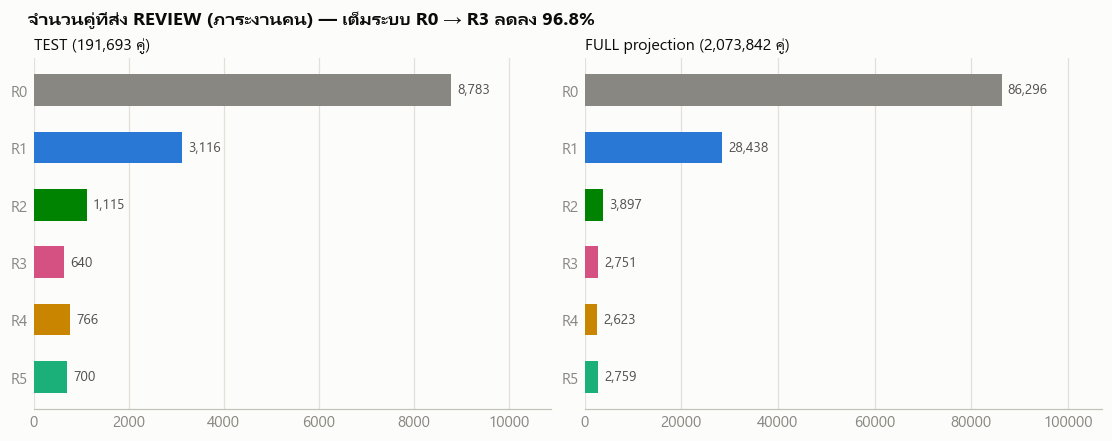

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.9), layout='constrained')
panels = [(test.loc[MAIN], 'TEST (191,693 คู่)'), (full.loc[MAIN], 'FULL projection (2,073,842 คู่)')]
for ax, (dd, title) in zip(axes, panels):
    colors = [EXP_COLORS[e] for e in dd.exp]
    bars = ax.barh(range(len(dd)), dd.REVIEW, height=0.55, color=colors)
    ax.set_yticks(range(len(dd)), [c.split(' · ')[0] for c in dd.index])
    ax.invert_yaxis()
    ax.bar_label(bars, labels=[f'{v:,.0f}' for v in dd.REVIEW], padding=4, fontsize=9, color=INK2)
    ax.set_xlim(0, dd.REVIEW.max() * 1.24)
    ax.set_title(title, fontsize=10.5, fontweight='normal')
    style_ax(ax, grid_axis='x')
fig.suptitle('จำนวนคู่ที่ส่ง REVIEW (ภาระงานคน) — เต็มระบบ R0 → R3 ลดลง 96.8%',
             x=0.02, ha='left', fontweight='bold', fontsize=12)
finish(fig, 'review_workload')


## 5. การกู้คืน False Negative — คู่จริงที่ production เคยปัดตก

pool คือ **2,242 คู่** ที่ `actual = 1` แต่ระบบ production ตัดสิน NO_MATCH ไปแล้ว — คำถามคือ representation + decision ใหม่ดึงกลับมาได้แค่ไหน

- **R2** (BERT + threshold มือ): กู้ได้ 282 คู่ (12.6%) — สัญญาณจาก BERT มีอยู่จริง แต่ threshold เก่าเปิดประตูให้แค่นิดเดียว
- **R3** (BERT + GA): กู้ได้ **728 คู่ (32.5%)** — เกือบ 3 เท่าของ R2 และในจำนวนนั้น 214 คู่กลับมาเป็น MATCH ตรง ๆ โดยไม่ต้องผ่านคนตรวจ

ผลนี้ตอกย้ำข้อสรุปหลักของการทดลองอีกครั้ง: representation ใหม่*ต้อง*มากับ decision rule ที่ re-tune แล้วเท่านั้น ถึงจะดึงคุณค่าออกมาได้


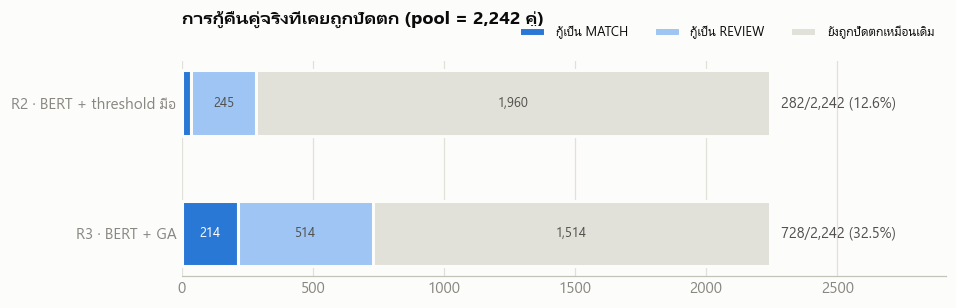

In [8]:
pool = rec['fn_pool_size']
data = {
    'R2 · BERT + threshold มือ': (rec['R2_recovered_to_MATCH'], rec['R2_recovered_any (MATCH or REVIEW)']),
    'R3 · BERT + GA':            (rec['R3_recovered_to_MATCH'], rec['R3_recovered_any (MATCH or REVIEW)']),
}

fig, ax = plt.subplots(figsize=(8.8, 2.9))
for i, (name, (to_match, any_rec)) in enumerate(data.items()):
    segs = [(to_match, '#2a78d6', 'กู้เป็น MATCH'),
            (any_rec - to_match, '#9ec5f4', 'กู้เป็น REVIEW'),
            (pool - any_rec, GRID, 'ยังถูกปัดตกเหมือนเดิม')]
    left = 0
    for v, c, lab in segs:
        ax.barh(i, v, left=left, height=0.5, color=c, edgecolor=SURFACE, linewidth=2,
                label=lab if i == 0 else None)
        left += v
        if v >= 150:  # ป้ายตัวเลขเฉพาะ segment ที่กว้างพอ
            ax.text(left - v / 2, i, f'{v:,}', va='center', ha='center', fontsize=8.5,
                    color='white' if c == '#2a78d6' else INK2)
    ax.text(pool * 1.02, i, f'{any_rec:,}/{pool:,} ({any_rec / pool:.1%})',
            va='center', fontsize=9.5, color=INK2)

ax.set_yticks(range(len(data)), list(data))
ax.invert_yaxis()
ax.set_xlim(0, pool * 1.30)
ax.legend(loc='upper right', frameon=False, fontsize=8.5, ncols=3, bbox_to_anchor=(1, 1.22))
ax.set_title(f'การกู้คืนคู่จริงที่เคยถูกปัดตก (pool = {pool:,} คู่)', pad=24)
style_ax(ax, grid_axis='x')
finish(fig, 'fn_recovery')


## 6. Privacy trade-off — Bloom filter (R4/R5)

R4/R5 แปลง `userName`/`fullName` เป็น **Bloom filter** (bit array ยาว L บิต, k=10 hash) ก่อน แล้วคำนวณ name similarity ด้วย **Dice coefficient** บนบิต → ระบบไม่ต้องเก็บ/ส่งชื่อ plaintext เลย
L ยิ่งสั้น บิตยิ่งชนกัน (collision) → similarity ยิ่งเพี้ยน → คาดว่า F1 จะไล่ลงเมื่อ L เล็กลง

ผลที่ได้:
- **R5 ที่ L=2000 ได้ F1 = 0.8329 ห่างจาก R3 แค่ 0.0044** — จ่ายราคาความแม่นยำนิดเดียวแลกกับ privacy เต็มรูปแบบ
- L เล็กลง (1000/500/250) เสื่อมแบบค่อยเป็นค่อยไปตามคาด (graceful degradation) ไม่มีจุดพังทลาย
- R4 (ไม่จูน GA) ติดอยู่แถว 0.73 ทุกค่า L — decision rule มีผลต่อคุณภาพมากกว่าความละเอียดของ Bloom filter เสียอีก

> ⚠️ บทเรียนเชิง implementation ที่เจอระหว่างรัน: สัญญาณ promote/demote ของ GA ใน R5 ต้องใช้ `name_sim_bloom` เท่านั้น — ถ้าเผลอใช้ `name_sim` (plaintext) จาก cache ของ R0/R1 การทดลอง privacy จะ**รั่ว plaintext ทางอ้อม**ทันที (bug นี้ถูกจับได้และแก้แล้ว)


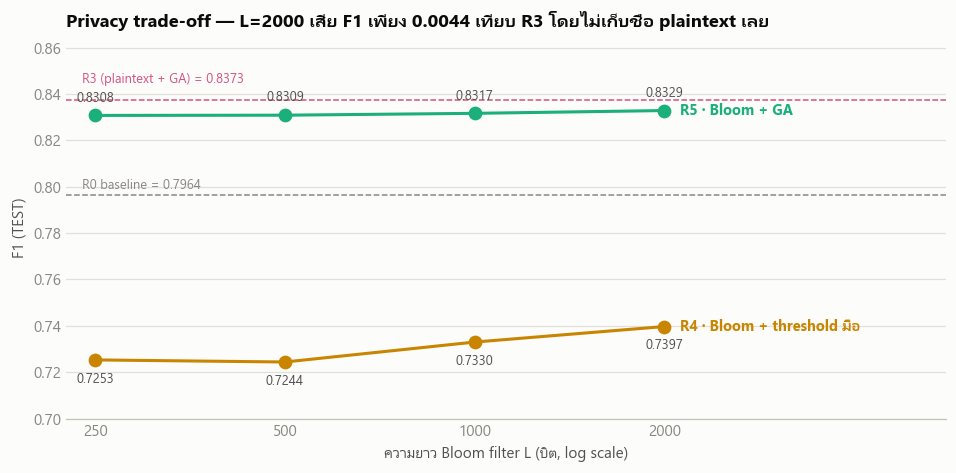

In [9]:
Ls = r4['L_values']  # [2000, 1000, 500, 250]
r4_f1 = [r4['per_L'][str(L)]['R4_manual']['test']['F1'] for L in Ls]
r5_f1 = [r4['per_L'][str(L)]['R5_ga']['test']['F1'] for L in Ls]
r3_f1 = test.loc['R3 · +BERT + GA', 'F1']
r0_f1 = test.loc['R0 · 17f + threshold มือ', 'F1']

fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.axhline(r3_f1, color=EXP_COLORS['R3'], linestyle='--', linewidth=1)
ax.axhline(r0_f1, color=MUTED, linestyle='--', linewidth=1)
ax.plot(Ls, r5_f1, marker='o', markersize=8, linewidth=2, color=EXP_COLORS['R5'])
ax.plot(Ls, r4_f1, marker='o', markersize=8, linewidth=2, color=EXP_COLORS['R4'])
for L, y in zip(Ls, r5_f1):
    ax.annotate(f'{y:.4f}', (L, y), textcoords='offset points', xytext=(0, 9), ha='center', fontsize=8.5, color=INK2)
for L, y in zip(Ls, r4_f1):
    ax.annotate(f'{y:.4f}', (L, y), textcoords='offset points', xytext=(0, -15), ha='center', fontsize=8.5, color=INK2)

ax.text(2000 * 1.06, r5_f1[0], 'R5 · Bloom + GA', color=EXP_COLORS['R5'], va='center', fontsize=9.5, fontweight='bold')
ax.text(2000 * 1.06, r4_f1[0], 'R4 · Bloom + threshold มือ', color=EXP_COLORS['R4'], va='center', fontsize=9.5, fontweight='bold')
ax.text(238, r3_f1 + 0.0075, f'R3 (plaintext + GA) = {r3_f1:.4f}', color=EXP_COLORS['R3'], fontsize=8.5)
ax.text(238, r0_f1 + 0.0025, f'R0 baseline = {r0_f1:.4f}', color=MUTED, fontsize=8.5)

ax.set_xscale('log', base=2)
ax.set_xticks(Ls)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlim(225, 5600)
ax.set_ylim(0.70, 0.865)
ax.set_xlabel('ความยาว Bloom filter L (บิต, log scale)')
ax.set_ylabel('F1 (TEST)')
ax.set_title('Privacy trade-off — L=2000 เสีย F1 เพียง 0.0044 เทียบ R3 โดยไม่เก็บชื่อ plaintext เลย')
style_ax(ax, grid_axis='y')
finish(fig, 'privacy_tradeoff')


## 7. การทำงานของ GA — convergence และ genome ที่เลือก


genome มี 4 ยีน: `t_m` (threshold ตัดสิน MATCH), `t_r` (threshold ส่ง REVIEW), `c_promote` / `c_demote` (เงื่อนไข promote/demote ด้วย name similarity — ฝั่ง R5 ใช้ `name_sim_bloom`)

จุดอ่านสำคัญจากตาราง genome ด้านล่าง: R1 ต้องตั้ง `t_m = 0.999` (เกือบสุดสเกล) เพราะ probability จาก representation เดิมแยกคู่จริง/ปลอมได้ไม่ขาด แต่พอมี BERT (R3) GA กล้าลด `t_m` เหลือ 0.980 และ `t_r` เหลือ 0.541 — แปลว่า distribution ใหม่แยกชัดขึ้นจน threshold ไม่ต้องเข้มเท่าเดิม ผลคือได้ทั้ง recall เพิ่มและ REVIEW ลดพร้อมกัน


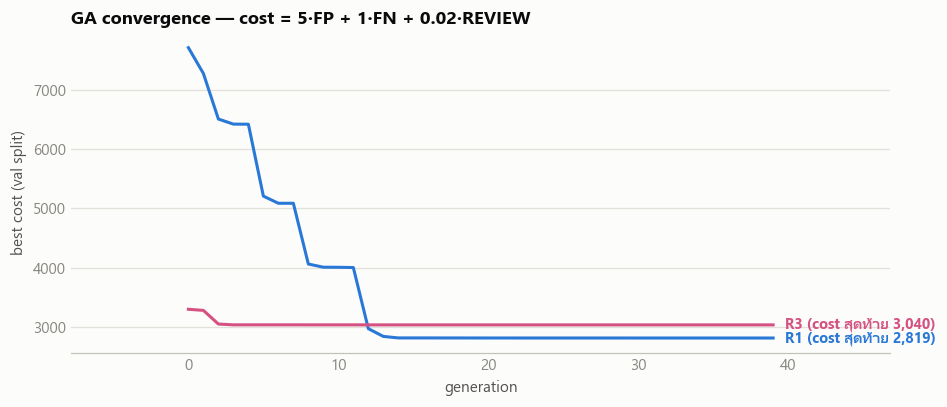

In [10]:
fig, ax = plt.subplots(figsize=(8.8, 3.8))
for name in ('R1', 'R3'):
    h = ga_hist[name]
    gens  = [p['gen'] for p in h]
    costs = [p['cost'] for p in h]
    ax.plot(gens, costs, linewidth=2, color=EXP_COLORS[name])
    ax.annotate(f'{name} (cost สุดท้าย {costs[-1]:,.0f})', (gens[-1], costs[-1]),
                textcoords='offset points', xytext=(8, 0), va='center',
                fontsize=9.5, color=EXP_COLORS[name], fontweight='bold')
ax.margins(x=0.20)
ax.set_xlabel('generation')
ax.set_ylabel('best cost (val split)')
ax.set_title('GA convergence — cost = 5·FP + 1·FN + 0.02·REVIEW')
style_ax(ax, grid_axis='y')
finish(fig, 'ga_convergence')


In [11]:
gen_rows = [{'rule': 'R1 (17f)', **r1['best_genome']},
            {'rule': 'R3 (+BERT)', **r3['best_genome']}]
for L in r4['L_values']:
    gen_rows.append({'rule': f'R5 (Bloom L={L})', **r4['per_L'][str(L)]['R5_best_genome']})

genomes = pd.DataFrame(gen_rows).set_index('rule')
(genomes.style
    .format('{:.4f}')
    .set_caption('genome ที่ GA เลือกในแต่ละการทดลอง — สังเกต t_m/t_r ของ R3/R5 ที่ต่ำกว่า R1 อย่างมีนัย'))


,t_m,t_r,c_promote,c_demote
rule,,,,
R1 (17f),0.9990,0.9642,0.9875,0.5052
R3 (+BERT),0.9803,0.5409,0.9872,0.4076
R5 (Bloom L=2000),0.9807,0.6050,0.9609,0.1446
R5 (Bloom L=1000),0.9860,0.5659,0.9627,0.1467
R5 (Bloom L=500),0.9990,0.5000,0.9682,0.1210
R5 (Bloom L=250),0.9990,0.5000,0.9777,0.3993


## 8. Projection เต็มระบบ (FULL: scored 2,073,842 คู่ + exact-tier)

ตัวเลขฝั่งนี้ตอบคำถาม "ถ้า deploy จริงจะเกิดอะไรขึ้น" — genome ถูกจูนบน val แล้ว apply กับ full ทั้งหมด (ตัวเลข unbiased สำหรับอ้างอิงเชิงวิชาการคือฝั่ง TEST ในหัวข้อ 1)


In [ ]:
full_main = full.loc[['R0 · 17f + threshold มือ', 'R1 · 17f + GA',
                      'R3 · +BERT + GA', 'R5 · Bloom L=2000 + GA'], list(METRICS)]

r0f, r3f = full_main.iloc[0], full_main.loc['R3 · +BERT + GA']
print(f'R0 → R3 :  FP {r0f.FP:,.0f} → {r3f.FP:,.0f} (-{1 - r3f.FP / r0f.FP:.1%})'
      f'   |   REVIEW {r0f.REVIEW:,.0f} → {r3f.REVIEW:,.0f} (-{1 - r3f.REVIEW / r0f.REVIEW:.1%})'
      f'   |   F1 {r0f.F1:.4f} → {r3f.F1:.4f}')

(full_main.style
    .format({'TP': '{:,.0f}', 'FP': '{:,.0f}', 'FN': '{:,.0f}', 'REVIEW': '{:,.0f}',
             'precision': '{:.4f}', 'recall': '{:.4f}', 'F1': '{:.4f}'})
    .highlight_max(subset=['F1'], props='font-weight:bold; background-color:#cde2fb;')
    .set_caption('Projection เต็มระบบ — แถวไฮไลต์ = F1 สูงสุด'))


R0 → R3 :  FP 925 → 465 (-49.7%)   |   REVIEW 86,296 → 2,751 (-96.8%)   |   F1 0.7882 → 0.8345


,TP,FP,FN,REVIEW,precision,recall,F1
config,,,,,,,
R0 · 17f + threshold มือ,"19,624",925,"5,558","86,296",0.9550,0.6710,0.7882
R1 · 17f + GA,"20,855",234,"6,284","28,438",0.9889,0.7131,0.8286
R3 · +BERT + GA,"21,274",465,"6,179","2,751",0.9786,0.7274,0.8345
R5 · Bloom L=2000 + GA,"21,135",648,"6,020","2,759",0.9703,0.7226,0.8283


: 

## 9. สรุป ข้อจำกัด และข้อเสนอแนะ

### สรุปผลหลัก
1. **BERT cosine (feature 18) ช่วยจริง แต่ต้องคู่กับ GA เท่านั้น** — R2 ที่ใช้ threshold มือเดิมกับ representation ใหม่ ได้ F1 แย่กว่า baseline ด้วยซ้ำ (0.7393 vs 0.7964) เพราะ scale ของ probability เปลี่ยนไปแล้ว
2. **R3 (BERT + GA) ดีที่สุดในทุกตัวชี้วัด**: F1 = 0.8373, REVIEW ลด 79% เทียบ R1, กู้ FN ที่เคยปัดตกได้ 728/2,242 คู่ (32.5%)
3. **R5 (Bloom L=2000 + GA) ตามหลัง R3 เพียง 0.0044 จุด F1** โดยไม่เก็บ `userName`/`fullName` เป็น plaintext เลย — เป็นตัวเลือกที่คุ้มที่สุดเมื่อมีข้อกำหนดด้าน privacy

### ข้อจำกัดของทุกการทดลองในชุดนี้
- **FN จาก blocking พลาด 3,316 คู่ กู้ไม่ได้** ด้วย decision rule หรือ representation ใด ๆ เพราะไม่เคยถูกสร้างเป็น candidate pair → เพดาน recall = (29,247 − 3,316) / 29,247 = **0.8866** — ต้องใช้ semantic/embedding blocking เป็น experiment แยกต่างหากถึงจะทะลุเพดานนี้ได้
- ตัวเลขฝั่ง FULL เป็น projection (genome จูนบน val) — เวลาอ้างอิงเชิงวิชาการให้ใช้ฝั่ง TEST

### ข้อเสนอแนะการ deploy
| เงื่อนไข | ใช้ config | เหตุผล |
|---|---|---|
| เก็บชื่อ plaintext ได้ | **R3** (BERT + GA) | F1 สูงสุด 0.8373, REVIEW เหลือ 640 (test) |
| มีข้อกำหนด privacy (ห้ามเก็บชื่อข้ามระบบ) | **R5 ที่ L=2000** | เสีย F1 แค่ 0.0044 แลกกับการไม่แตะ plaintext เลย |

ทั้งสองกรณี: **ห้าม**นำ threshold มือ 0.98/0.95 เดิมไปใช้กับโมเดลใหม่ (บทเรียนจาก R2/R4) และถ้าต้องการดัน recall เกิน 0.887 ต้องแก้ปัญหา blocking ก่อนเป็นลำดับแรก
